#                                                           Multilingual Mobile App Reviews Dataset Analysis

# Importing Dependencies

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Loading the dataset 

In [3]:
df=pd.read_csv('multilingual_mobile_app_reviews_2025.csv')

# Understanding the data

In [4]:
df.head()

,review_id,user_id,app_name,app_category,review_text,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,user_gender,app_version
0,1,1967825,MX Player,Travel & Local,Qui doloribus consequuntur. Perspiciatis tempo...,no,1.3,2024-10-09 19:26:40,True,Android Tablet,65,14.0,China,Female,1.4
1,2,9242600,Tinder,Navigation,"Great app but too many ads, consider premium v...",ru,1.6,2024-06-21 17:29:40,True,iPad,209,18.0,Germany,Male,8.9
2,3,7636477,Netflix,Dating,The interface could be better but overall good...,es,3.6,2024-10-31 13:47:12,True,iPad,163,67.0,Nigeria,Male,2.8.37.5926
3,4,209031,Venmo,Productivity,"Latest update broke some features, please fix ...",vi,3.8,2025-03-12 06:16:22,True,iOS,664,66.0,India,Female,10.2
4,5,7190293,Google Drive,Education,"Perfect for daily use, highly recommend to eve...",tl,3.2,2024-04-21 03:48:27,True,iPad,1197,40.0,South Korea,Prefer not to say,4.7


In [5]:
df.tail()

,review_id,user_id,app_name,app_category,review_text,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,user_gender,app_version
2509,2510,2322118,OneDrive,Business,Счастье низкий пастух. Нож неожиданно поезд тр...,nl,3.0,2023-11-23 01:07:30,False,iOS,635,21.0,Malaysia,Non-binary,1.1.2-beta
2510,2511,2167693,Signal,Finance,This app is amazing! Really love the new featu...,ms,1.9,2025-06-05 16:42:20,True,Windows Phone,1127,38.0,Bangladesh,NaN,v12.0.80
2511,2512,5554467,OneDrive,Social Networking,This app is amazing! Really love the new featu...,zh,3.4,2024-06-15 05:02:18,True,Android Tablet,677,27.0,Pakistan,NaN,9.1.32.4821
2512,2513,8805125,Coursera,Social Networking,Invitare convincere pericoloso corsa fortuna. ...,da,2.7,2023-12-02 01:41:31,True,Android,155,35.0,India,NaN,v8.9.13
2513,2514,1099793,Venmo,Education,"Latest update broke some features, please fix ...",it,2.1,2025-03-04 02:51:17,True,Android,1040,26.0,Bangladesh,Prefer not to say,2.2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          2514 non-null   int64  
 1   user_id            2514 non-null   int64  
 2   app_name           2514 non-null   object 
 3   app_category       2514 non-null   object 
 4   review_text        2455 non-null   object 
 5   review_language    2514 non-null   object 
 6   rating             2477 non-null   float64
 7   review_date        2514 non-null   object 
 8   verified_purchase  2514 non-null   bool   
 9   device_type        2514 non-null   object 
 10  num_helpful_votes  2514 non-null   int64  
 11  user_age           2514 non-null   float64
 12  user_country       2473 non-null   object 
 13  user_gender        1927 non-null   object 
 14  app_version        2484 non-null   object 
dtypes: bool(1), float64(2), int64(3), object(9)
memory usage: 277.6+ KB


# Observation:

Review text ,rating ,user_country ,user_gender,app_version has null values

we can replace mode values for review text user_country and app version
rating with mean value

# column description

review_id → Unique identifier for each review.

user_id → Unique identifier for the user who wrote the review.

app_name → Name of the mobile application being reviewed.

app_category → Category/genre of the app (e.g., Games, Finance, Health).

review_text → Written text of the user’s review.

review_language → Language in which the review is written.

rating → Star rating or numeric score given by the user.

review_date → Date when the review was submitted.

verified_purchase → Whether the review is from a verified purchase (Yes/No).

device_type → Type of device used (e.g., Android, iOS, Tablet).

num_helpful_votes → Number of people who found the review helpful.

user_age → Age of the user writing the review.

user_country → Country of the user.

user_gender → Gender of the user.

app_version → Version of the app being reviewed.

# Data Cleaning

In [7]:
df.duplicated().any()

np.False_

In [8]:
df=df.drop(columns=['review_id'])

In [9]:
df['review_language'].unique()
df['review_language']=df['review_language'].replace({'no':'Norwegian','ru':'Russian','es':'Spanish','vi':'Vietnamese','tl':'Tagalog (Filipino)','th':'Thai','da':'Danish','ja':'Japanese','ms':'Malay','fr':'French','it':'Italian','nl':'Dutch','hi':'Hindi','ar':'Arabic','zh':'Chinese','id':'Indonesian','pl':'Polish','ko':'Korean','sv':'Swedish','pt':'Portuguese','tr':'Turkish','fi':'Finnish','de':'German','en':'English'})


In [10]:

df['rating']=df['rating'].fillna(df['rating'].mean())
df['user_country']=df['user_country'].fillna('Unknown')
df['user_gender']=df['user_gender'].fillna('Unknown')
df['review_text']=df['review_text'].fillna('Unknown')
df['app_version']=df['app_version'].fillna('Unknown')

In [11]:
df['user_age']=df['user_age'].astype(int)

In [12]:
df['user_age'].max()

np.int64(75)

In [13]:
df['age_group']=pd.cut(df['user_age'],bins=[13,26,50,75],labels=['Teen','Mid-Senior','Senior'])


In [14]:
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# make observation
1. Which factors do you think most strongly influence the rating of an app? Why?

2. How might review_language affect the interpretation of user satisfaction?

3. Explain how app_version and review_date together can show app improvement or decline.

4. Do you think verified_purchase makes reviews more trustworthy? Justify your answer.

5. How would you test whether device_type has an impact on app ratings?

6. If you had to find which age group is most satisfied, what steps would you follow?

7. How would you identify fake or unreliable reviews using num_helpful_votes and review_text?

1. Which factors do you think most strongly influence the rating of an app? Why?

In [15]:
category_ratings = df.groupby('app_category')['rating'].mean().sort_values(ascending=False)
category_ratings


app_category
Health & Fitness           3.250594
Navigation                 3.107453
Entertainment              3.098109
Utilities                  3.082792
Games                      3.065992
Video Players & Editors    3.064748
Photography                3.047175
Business                   3.043614
Music & Audio              3.020810
Social Networking          3.014388
Education                  3.005766
Communication              2.993161
Shopping                   2.978140
Finance                    2.974219
Productivity               2.968007
News & Magazines           2.927226
Dating                     2.877894
Travel & Local             2.842535
Name: rating, dtype: float64

In [16]:
verified_ratings = df.groupby('verified_purchase')['rating'].describe()
verified_ratings


,count,mean,std,min,25%,50%,75%,max
verified_purchase,,,,,,,,
False,575.0,2.985373,1.134509,1.0,2.0,3.000000,3.9,5.0
True,1939.0,3.031609,1.143588,1.0,2.1,3.021034,4.0,5.0


In [17]:
device_ratings = df.groupby('device_type')['rating'].mean().sort_values(ascending=False)
device_ratings


device_type
Android Tablet    3.064223
iOS               3.063063
iPad              3.037398
Windows Phone     2.980087
Android           2.963846
Name: rating, dtype: float64

In [18]:
gender_ratings = df.groupby('user_gender')['rating'].mean()
gender_ratings


user_gender
Female               3.050281
Male                 2.979395
Non-binary           2.975449
Prefer not to say    3.093546
Unknown              3.010983
Name: rating, dtype: float64

In [19]:
age_ratings = df.groupby('age_group')['rating'].mean().sort_values(ascending=False)
age_ratings


D:\\ipykernel_19980\3226446674.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_ratings = df.groupby('age_group')['rating'].mean().sort_values(ascending=False)


age_group
Senior        3.055146
Teen          3.050468
Mid-Senior    2.974297
Name: rating, dtype: float64

In [20]:
version_ratings = df.groupby('app_version')['rating'].mean().sort_values(ascending=False)
version_ratings


app_version
1.2.92.3702    5.0
1.2.39         5.0
1.2.30         5.0
v8.6.18        5.0
8.6.37-beta    5.0
              ... 
v11.2.23       1.0
v12.7.84       1.0
v7.8.57        1.0
1.0.50.4717    1.0
1.0.45.7154    1.0
Name: rating, Length: 2082, dtype: float64

OBSERVATION:

app_version plays an important role in the ratings Newer versions will have updations hence gets positive ratings

verified_purchase has impact on rating coz non-verfied apps may have fake reviews mixed with it

App category has one of the strongest influences on user ratings Developers should prioritize features, design, and performance based on the category to maximize satisfaction.

2. How might review_language affect the interpretation of user satisfaction?

In [22]:
df['review_language'].value_counts()

review_language
Russian               134
Polish                122
Spanish               119
Dutch                 116
Tagalog (Filipino)    114
Korean                114
Indonesian            111
Finnish               111
Arabic                108
Danish                105
Norwegian             103
Swedish               102
Turkish               102
German                102
Vietnamese            100
Italian               100
English                99
Chinese                98
Thai                   97
Japanese               94
Portuguese             93
Hindi                  92
French                 90
Malay                  88
Name: count, dtype: int64

In [24]:
language_avg=df.groupby('review_language')['rating'].mean().sort_values(ascending=False)
language_avg


review_language
Danish                3.246867
Spanish               3.194294
French                3.174678
Tagalog (Filipino)    3.121237
Russian               3.116418
Hindi                 3.114359
Korean                3.076316
Arabic                3.071149
German                3.061403
English               3.059808
Vietnamese            3.050000
Thai                  3.039826
Italian               3.025421
Norwegian             3.022943
Finnish               2.986486
Malay                 2.966387
Dutch                 2.965699
Indonesian            2.965054
Swedish               2.926315
Turkish               2.908049
Japanese              2.877043
Portuguese            2.843463
Chinese               2.837164
Polish                2.812467
Name: rating, dtype: float64

In [ ]:
lang_counts=df.groupby('review_language')['rating'].agg(['count','mean']).sort_values('mean',ascending=False)

,count,mean
review_language,,
Danish,105,3.246867
Spanish,119,3.194294
French,90,3.174678
Tagalog (Filipino),114,3.121237
Russian,134,3.116418
Hindi,92,3.114359
Korean,114,3.076316
Arabic,108,3.071149
German,102,3.061403


In [ ]:
lang_counts=lang_counts

OBSERVATION:

Hight count and high rating shows high satisfaction

high count and low rating shows lower satisfaction

low count and high rating we cannot conclude the satisfaction



3. Explain how app_version and review_date together can show app improvement or decline.

4. Does verified_purchase make reviews more trustworthy?

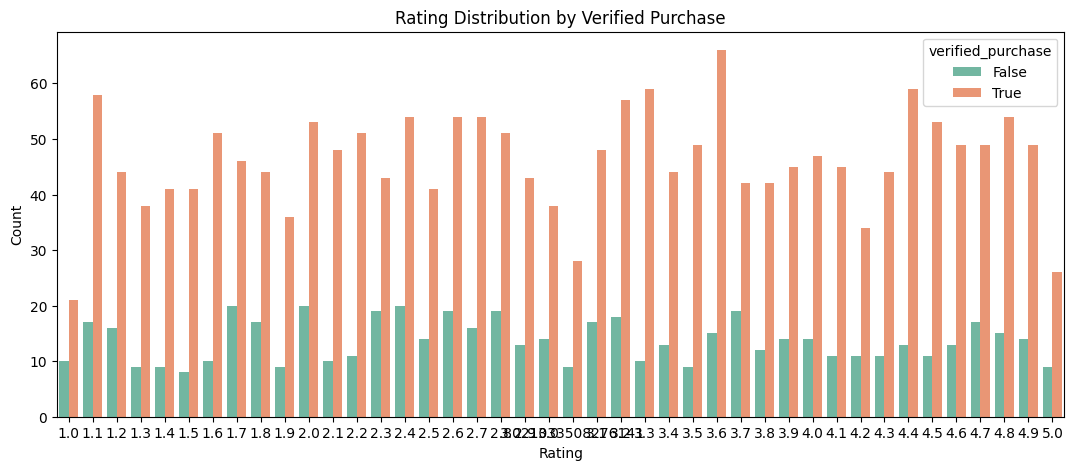

In [ ]:
plt.figure(figsize=(13,5))
sns.countplot(x='rating', hue='verified_purchase', data=df, palette='Set2')
plt.title('Rating Distribution by Verified Purchase')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


OBSERVATION:

Most ratings come from verified users (orange bars).

Non-verified ratings (green bars) are much fewer in every rating category.

5. How to test whether device_type impacts app ratings?

In [ ]:
# Average rating by device
df.groupby('device_type')['rating'].mean().sort_values(ascending=False)


device_type
Android Tablet    3.064223
iOS               3.063063
iPad              3.037398
Windows Phone     2.980087
Android           2.963846
Name: rating, dtype: float64

OBSERVATION:

Device type does not effect rating

6. If you had to find which age group is most satisfied, what steps would you follow?

Group data by age_group.

Calculate average rating for each group.

Compare ratings across groups.

In [ ]:
df.groupby('age_group')['rating'].mean().sort_values(ascending=False)


D:\\ipykernel_20840\1553313614.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['rating'].mean().sort_values(ascending=False)


age_group
Senior        3.055146
Teen          3.050468
Mid-Senior    2.974297
Name: rating, dtype: float64

7. Identify fake/unreliable reviews using num_helpful_votes and review_text

In [ ]:
# Flag suspicious reviews
sus= (df['num_helpful_votes'] == 0) & (df['review_text'].str.len() < 20)
sus.any()


np.False_

# conclusion:

The target is to find out what factors (language, gender, age, purchase status, category, version, device, etc.) most influence user ratings and satisfaction

Factors influencing ratings most strongly: app_category, verified_purchase, app_version.


# Suppose you are an app developer: what insights from this dataset would help you improve
your app?

Focus on app category trends → prioritize features that users of that category value.

Monitor device-specific issues and optimize performance.

Track updates over time → ensure ratings improve with each release.

Encourage verified purchases for more trustworthy feedback.

# Propose one machine learning project idea using this dataset and describe its expected outcome

Project: Predict App Rating from Review Text and Metadata

Input Features: review_text, review_language, app_category, verified_purchase, device_type, age_group.

Target: rating (1–5)

Expected Outcome:

Predict user ratings from textual and categorical metadata.

Identify potential high/low-rated reviews before publication.

Detect patterns that improve app quality.

# language reference



| Code   | Language           |
| ------ | ------------------ |
| **no** | Norwegian          |
| **ru** | Russian            |
| **es** | Spanish            |
| **vi** | Vietnamese         |
| **tl** | Tagalog (Filipino) |
| **th** | Thai               |
| **da** | Danish             |
| **ja** | Japanese           |
| **ms** | Malay              |
| **fr** | French             |
| **it** | Italian            |
| **nl** | Dutch              |
| **hi** | Hindi              |
| **ar** | Arabic             |
| **zh** | Chinese            |
| **id** | Indonesian         |
| **pl** | Polish             |
| **ko** | Korean             |
| **sv** | Swedish            |
| **pt** | Portuguese         |
| **tr** | Turkish            |
| **fi** | Finnish            |
| **de** | German             |
| **en** | English            |
